Tiempo de encuentro = 3.0 s
Altura de encuentro = 75.85499999999999 m
Velocidad pelota 1 = 10.57 m/s
Velocidad pelota 2 = -19.43 m/s


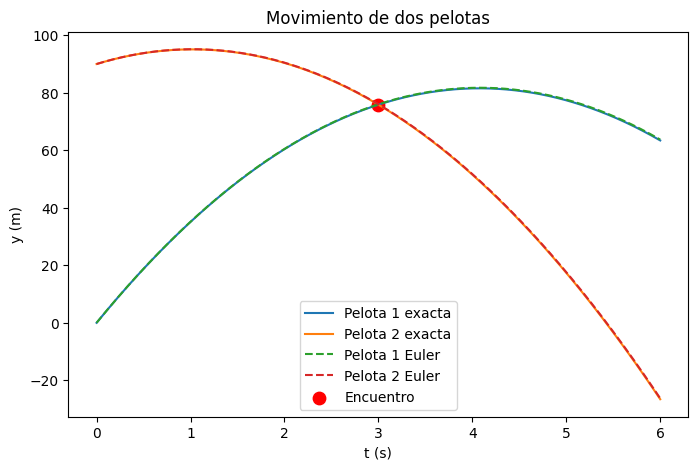

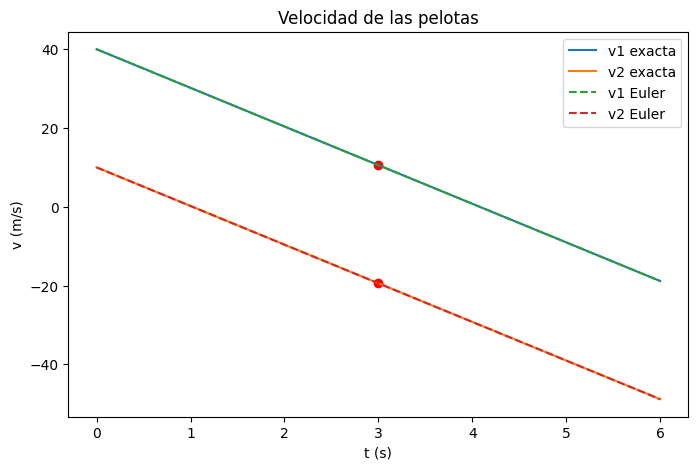

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# Parámetros físicos
# -----------------------------
g = 9.81

# Pelota 1
y10 = 0.0
v10 = 40.0

# Pelota 2
y20 = 90.0
v20 = 10.0

# -----------------------------
# Parámetros numéricos
# -----------------------------
dt = 0.01
t_total = 6
N = int(t_total/dt) + 1

# -----------------------------
# Arreglos Euler
# -----------------------------
t = np.zeros(N)

y1 = np.zeros(N)
v1 = np.zeros(N)

y2 = np.zeros(N)
v2 = np.zeros(N)

# Condiciones iniciales
y1[0] = y10
v1[0] = v10

y2[0] = y20
v2[0] = v20

# -----------------------------
# Integración Euler
# -----------------------------
for n in range(N-1):

    t[n+1] = t[n] + dt

    y1[n+1] = y1[n] + dt*v1[n]
    v1[n+1] = v1[n] - g*dt

    y2[n+1] = y2[n] + dt*v2[n]
    v2[n+1] = v2[n] - g*dt

# -----------------------------
# Solución exacta
# -----------------------------
t_exact = np.linspace(0,t_total,2000)

y1_exact = y10 + v10*t_exact - 0.5*g*t_exact**2
v1_exact = v10 - g*t_exact

y2_exact = y20 + v20*t_exact - 0.5*g*t_exact**2
v2_exact = v20 - g*t_exact

# -----------------------------
# Encuentro exacto
# -----------------------------
t_meet = (y20-y10)/(v10-v20)
y_meet = y10 + v10*t_meet - 0.5*g*t_meet**2

v1_meet = v10 - g*t_meet
v2_meet = v20 - g*t_meet

print("Tiempo de encuentro =",t_meet,"s")
print("Altura de encuentro =",y_meet,"m")
print("Velocidad pelota 1 =",v1_meet,"m/s")
print("Velocidad pelota 2 =",v2_meet,"m/s")

# -----------------------------
# Gráfica posiciones
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(t_exact,y1_exact,label="Pelota 1 exacta")
plt.plot(t_exact,y2_exact,label="Pelota 2 exacta")

plt.plot(t,y1,'--',label="Pelota 1 Euler")
plt.plot(t,y2,'--',label="Pelota 2 Euler")

plt.scatter(t_meet,y_meet,s=80,color='red',label="Encuentro")

plt.xlabel("t (s)")
plt.ylabel("y (m)")
plt.title("Movimiento de dos pelotas")
plt.legend()
plt.savefig("Movimiento2Pelotas.pdf", dpi=300, bbox_inches='tight')

plt.show()

# -----------------------------
# Gráfica velocidades
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(t_exact,v1_exact,label="v1 exacta")
plt.plot(t_exact,v2_exact,label="v2 exacta")

plt.plot(t,v1,'--',label="v1 Euler")
plt.plot(t,v2,'--',label="v2 Euler")

plt.scatter(t_meet,v1_meet,color='red')
plt.scatter(t_meet,v2_meet,color='red')

plt.xlabel("t (s)")
plt.ylabel("v (m/s)")
plt.title("Velocidad de las pelotas")
plt.legend()
plt.savefig("Velocidad2Pelotas.pdf", dpi=300, bbox_inches='tight')

plt.show()

# -----------------------------
# Descargar archivos
# -----------------------------
files.download("Movimiento2Pelotas.pdf")
files.download("Velocidad2Pelotas.pdf")